# Pacing response

In [1]:
using ModelingToolkit
using OrdinaryDiffEq, SteadyStateDiffEq, DiffEqCallbacks
using Plots
using CSV
using DataFrames
using CaMKIIModel
using CaMKIIModel: second
Plots.default(lw=1.5)

## Setup the ODE system
Electrical stimulation starts at `t`=100 seconds and ends at `t`=300 seconds.

In [2]:
sys = build_neonatal_ecc_sys(simplify=true, reduce_iso=true, reduce_camk=true)
tend = 500.0second
prob = ODEProblem(sys, [], tend)
stimstart = 100.0second
stimend = 300.0second
@unpack Istim = sys
alg = KenCarp47()

KenCarp47(; linsolve = nothing, nlsolve = OrdinaryDiffEqNonlinearSolve.NLNewton{Rational{Int64}, Rational{Int64}, Rational{Int64}, Rational{Int64}}(1//100, 10, 1//5, 1//5, false, true, 0//1), precs = DEFAULT_PRECS, smooth_est = true, extrapolant = linear, controller = PI, autodiff = ADTypes.AutoForwardDiff(),)

## Single pulse

In [3]:
callback = build_stim_callbacks(Istim, stimstart + 1second; period=10second, starttime=stimstart)

@time sol = solve(prob, alg; callback)

  8.757032 seconds (23.36 M allocations: 1.073 GiB, 4.91% gc time, 99.45% compilation time)


retcode: Success
Interpolation: 3rd order Hermite
t: 132-element Vector{Float64}:
      0.0
      0.019333123284849308
      0.09098129546757994
      0.20735582943983855
      0.45611910276862533
      1.0472562928406122
      2.0342667657223696
      3.451776641148454
      6.733792423912806
     12.450117081023194
      ⋮
 230382.17301929306
 250334.23713307502
 276733.091042313
 305589.8673114139
 343648.59083174216
 381707.3143520704
 426137.67107672844
 478963.9250696174
 500000.0
u: 132-element Vector{Vector{Float64}}:
 [0.0026, 830.0, 830.0, 0.00702, 0.966, 0.22156, 0.09243, 0.00188, 0.00977, 0.26081  …  0.12113, 0.12113, 0.12113, 0.12113, 0.12113, 0.12113, 0.12113, -68.79268, 13838.37602, 150952.75035000002]
 [0.0025985659590295374, 829.9994975880693, 829.9999654017583, 0.007020208561323646, 0.9660018276402699, 0.2215639938807744, 0.09242766669618695, 0.001879826176081169, 0.009769882842069916, 0.2608055799112056  …  0.12113000000000405, 0.12113000000038378, 0.1211300000138938

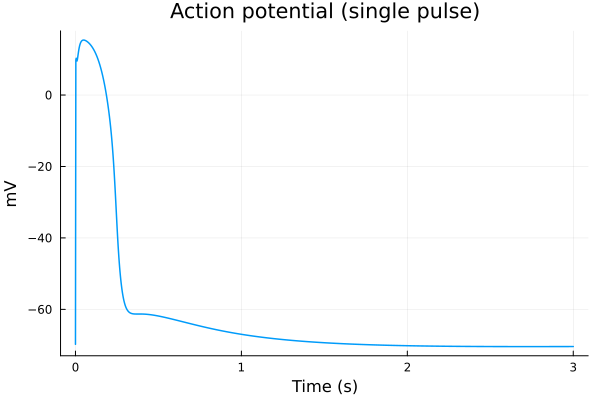

In [4]:
plot(sol, idxs=(sys.t / 1000 - 100, sys.vm), title="Action potential (single pulse)", ylabel="mV", xlabel="Time (s)", label=false, tspan=(100second, 103second))

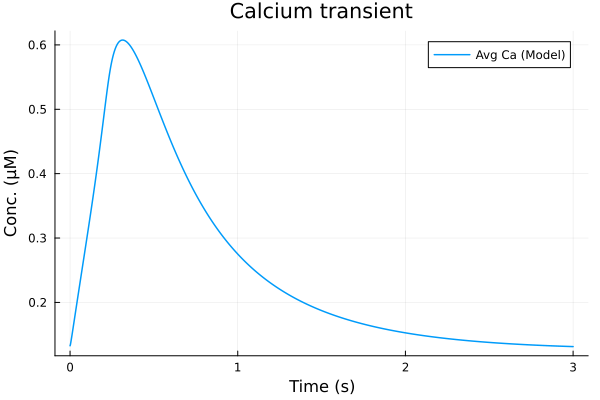

In [5]:
plot(sol, idxs=(sys.t / 1000 - 100, sys.Cai_mean), tspan=(100second, 103second), title="Calcium transient", ylabel="Conc. (μM)", xlabel="Time (s)", label="Avg Ca (Model)")

In [6]:
savefig("single-cat.pdf")

"/home/github/actions-runner-1/_work/camkii-cardiomyocyte-model/camkii-cardiomyocyte-model/.cache/docs/single-cat.pdf"

## 1Hz

In [7]:
callback = build_stim_callbacks(Istim, stimend; period=1second, starttime=stimstart)
@time sol = solve(prob, alg; callback)

  2.681453 seconds (78.83 k allocations: 18.272 MiB)


retcode: Success
Interpolation: 3rd order Hermite
t: 8928-element Vector{Float64}:
      0.0
      0.019333123284849308
      0.09098129546757994
      0.20735582943983855
      0.45611910276862533
      1.0472562928406122
      2.0342667657223696
      3.451776641148454
      6.733792423912806
     12.450117081023194
      ⋮
 397420.7293508087
 407496.2619864756
 419304.0528694844
 431111.8437524932
 444428.3784047912
 459536.4436840207
 475039.8195722815
 494235.3907788104
 500000.0
u: 8928-element Vector{Vector{Float64}}:
 [0.0026, 830.0, 830.0, 0.00702, 0.966, 0.22156, 0.09243, 0.00188, 0.00977, 0.26081  …  0.12113, 0.12113, 0.12113, 0.12113, 0.12113, 0.12113, 0.12113, -68.79268, 13838.37602, 150952.75035000002]
 [0.0025985659590295374, 829.9994975880693, 829.9999654017583, 0.007020208561323646, 0.9660018276402699, 0.2215639938807744, 0.09242766669618695, 0.001879826176081169, 0.009769882842069916, 0.2608055799112056  …  0.12113000000000405, 0.12113000000038378, 0.12113000001389383

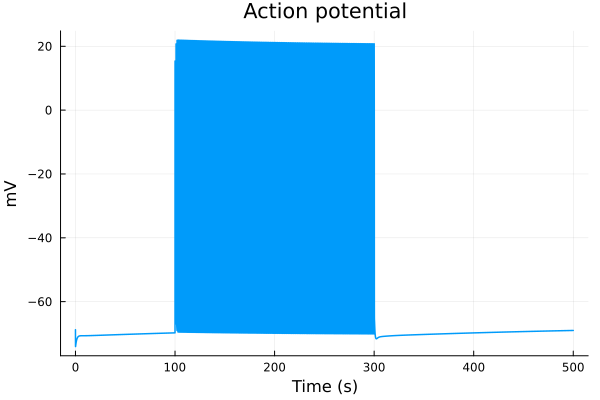

In [8]:
plot(sol, idxs=(sys.t / 1000, sys.vm), title="Action potential", ylabel="mV", xlabel="Time (s)", label=false)

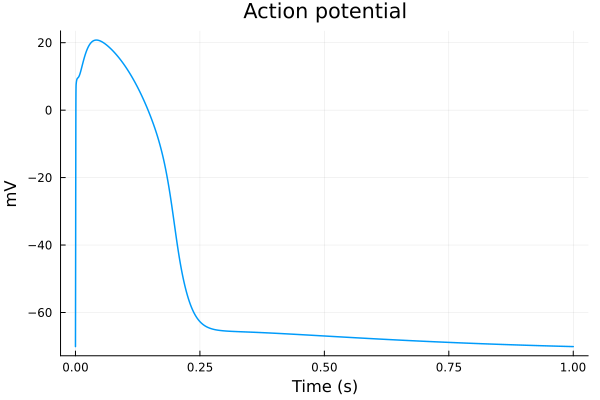

In [9]:
plot(sol, idxs=(sys.t / 1000 - 299, sys.vm), title="Action potential", tspan=(299second, 300second), ylabel="mV", xlabel="Time (s)", label=false)

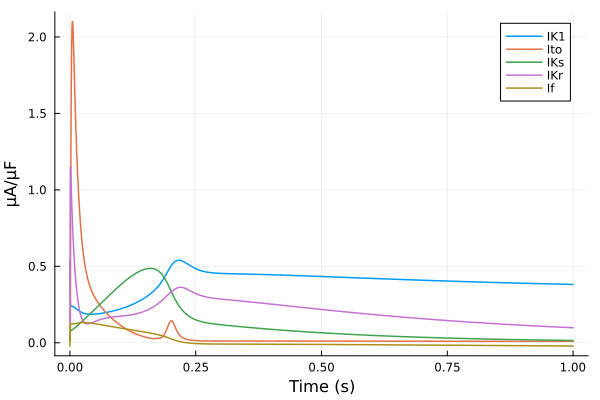

In [10]:
plot(sol, idxs=(sys.t / 1000 - 299, [sys.IK1, sys.Ito, sys.IKs, sys.IKr, sys.If]), tspan=(299second, 300second), ylabel="μA/μF", xlabel="Time (s)", label=["IK1" "Ito" "IKs" "IKr" "If"])

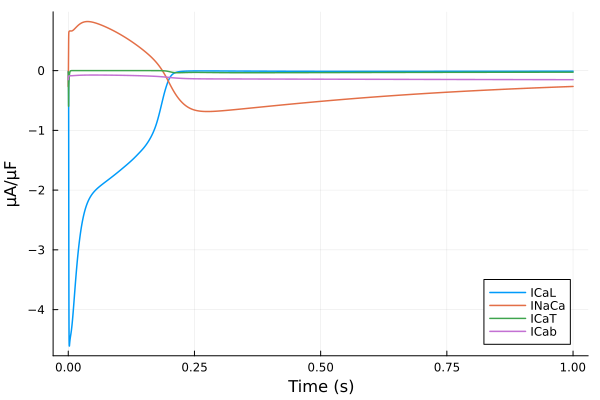

In [11]:
plot(sol, idxs=(sys.t / 1000 - 299, [sys.ICaL, sys.INaCa, sys.ICaT, sys.ICab]), tspan=(299second, 300second), ylabel="μA/μF", xlabel="Time (s)", label=["ICaL" "INaCa" "ICaT" "ICab"])

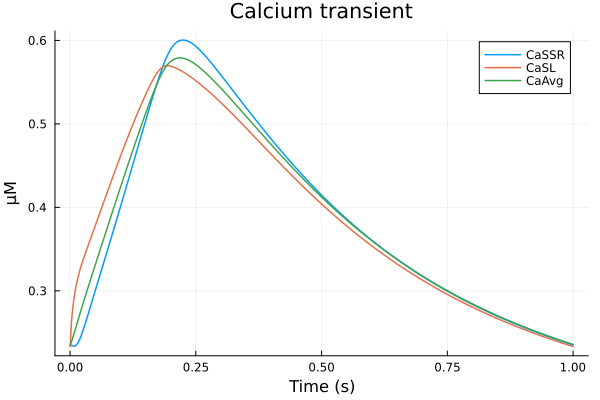

In [12]:
plot(sol, idxs=(sys.t / 1000 - 299, [sys.Cai_sub_SR, sys.Cai_sub_SL, sys.Cai_mean]), tspan=(299second, 300second), title="Calcium transient", ylabel="μM", xlabel="Time (s)", label=["CaSSR" "CaSL" "CaAvg"])

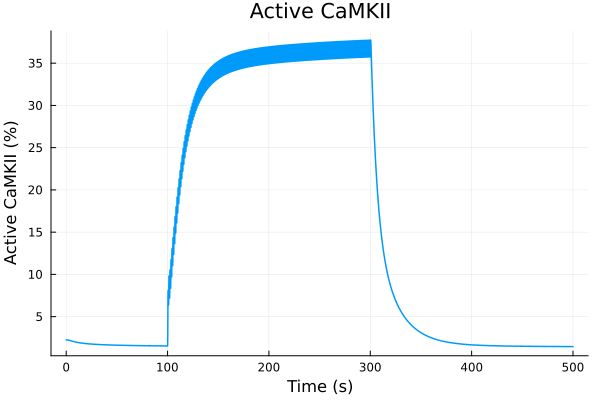

In [13]:
plot(sol, idxs=(sys.t / 1000, sys.CaMKAct * 100), title="Active CaMKII", ylabel="Active CaMKII (%)", xlabel="Time (s)", label=false)

### 3D surface plot

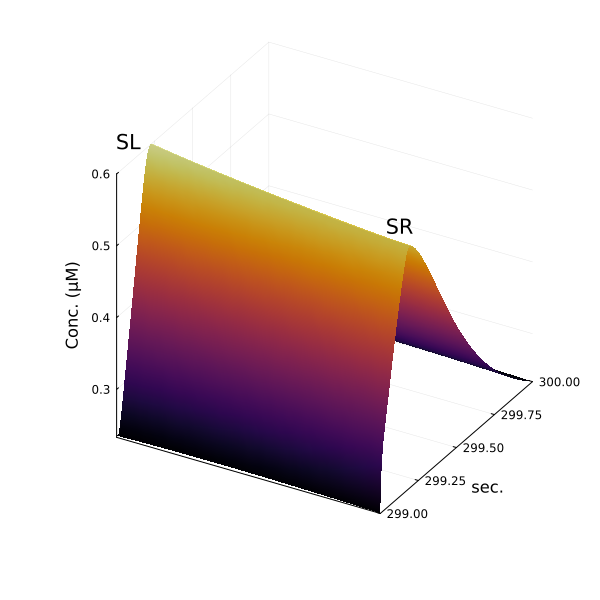

In [14]:
xx = 1:44
yy = range(299second, 300second, length=100)
zz = [sol(t, idxs=sys.Cai[u]) for t in yy, u in xx]

surface(xx, yy ./ 1000, zz, colorbar=:none, yguide="sec.", zguide="Conc. (μM)", xticks=false, size=(600, 600))
annotate!(3, 299, 0.65, "SL")
annotate!(41, 299.25, 0.58, "SR")

In [15]:
savefig("3d-surface.pdf")

"/home/github/actions-runner-1/_work/camkii-cardiomyocyte-model/camkii-cardiomyocyte-model/.cache/docs/3d-surface.pdf"

## 2Hz

In [16]:
callback = build_stim_callbacks(Istim, stimend; period=1 / 2 * second, starttime=stimstart)
@time sol2 = solve(prob, alg; callback)

  4.644326 seconds (122.72 k allocations: 29.268 MiB)


retcode: Success
Interpolation: 3rd order Hermite
t: 14163-element Vector{Float64}:
      0.0
      0.019333123284849308
      0.09098129546757994
      0.20735582943983855
      0.45611910276862533
      1.0472562928406122
      2.0342667657223696
      3.451776641148454
      6.733792423912806
     12.450117081023194
      ⋮
 403252.8064076104
 412782.91906571155
 423257.62396415835
 435362.5046771487
 447467.38539013907
 461423.863562818
 478496.3270349015
 495568.790506985
 500000.0
u: 14163-element Vector{Vector{Float64}}:
 [0.0026, 830.0, 830.0, 0.00702, 0.966, 0.22156, 0.09243, 0.00188, 0.00977, 0.26081  …  0.12113, 0.12113, 0.12113, 0.12113, 0.12113, 0.12113, 0.12113, -68.79268, 13838.37602, 150952.75035000002]
 [0.0025985659590295374, 829.9994975880693, 829.9999654017583, 0.007020208561323646, 0.9660018276402699, 0.2215639938807744, 0.09242766669618695, 0.001879826176081169, 0.009769882842069916, 0.2608055799112056  …  0.12113000000000405, 0.12113000000038378, 0.12113000001389

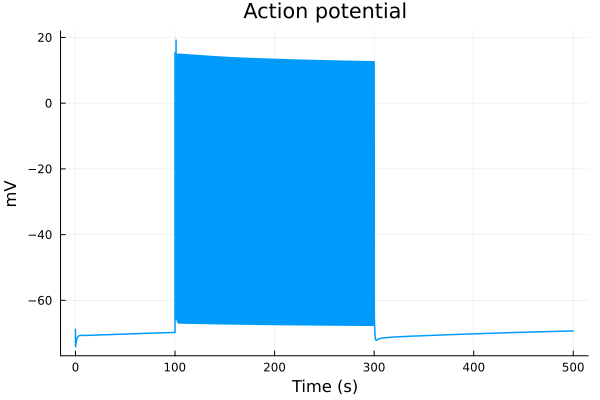

In [17]:
plot(sol2, idxs=(sys.t / 1000, sys.vm), title="Action potential", ylabel="mV", xlabel="Time (s)", label=false)

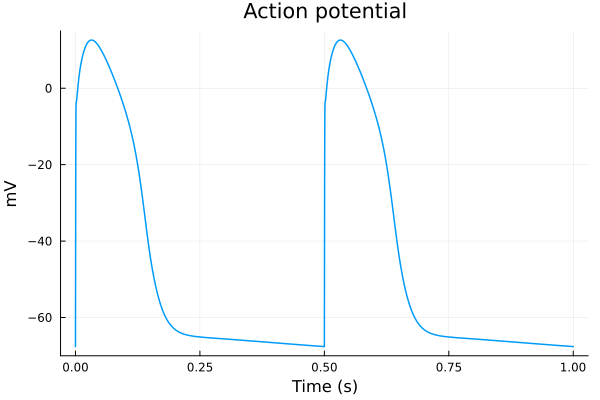

In [18]:
plot(sol2, idxs=(sys.t / 1000 - 299, sys.vm), title="Action potential", tspan=(299second, 300second), ylabel="mV", xlabel="Time (s)", label=false)

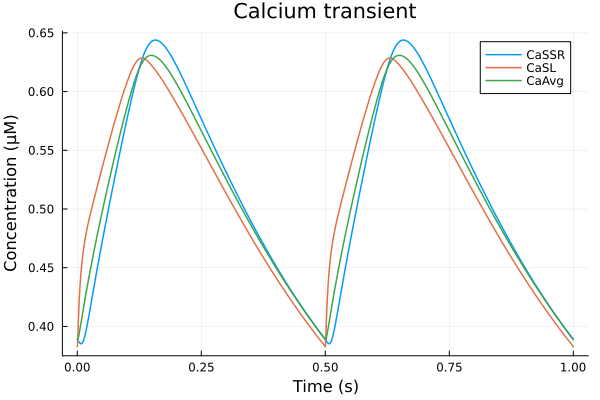

In [19]:
plot(sol2, idxs=(sys.t / 1000 - 299, [sys.Cai_sub_SR, sys.Cai_sub_SL, sys.Cai_mean]), tspan=(299second, 300second), title="Calcium transient", ylabel="Concentration (μM)", xlabel="Time (s)", label=["CaSSR" "CaSL" "CaAvg"])

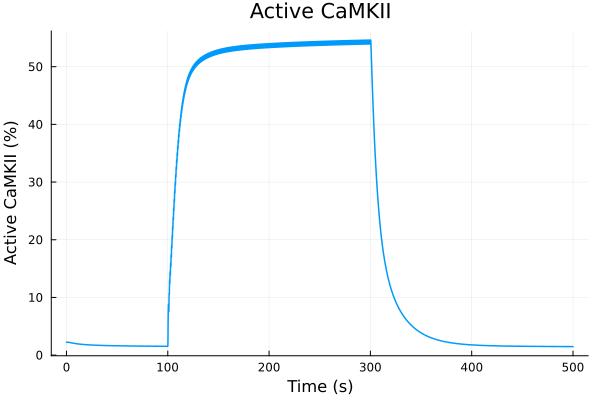

In [20]:
plot(sol2, idxs=(sys.t / 1000, sys.CaMKAct * 100), title="Active CaMKII", ylabel="Active CaMKII (%)", xlabel="Time (s)", label=false)

## Comparing 1 and 2 Hz pacing

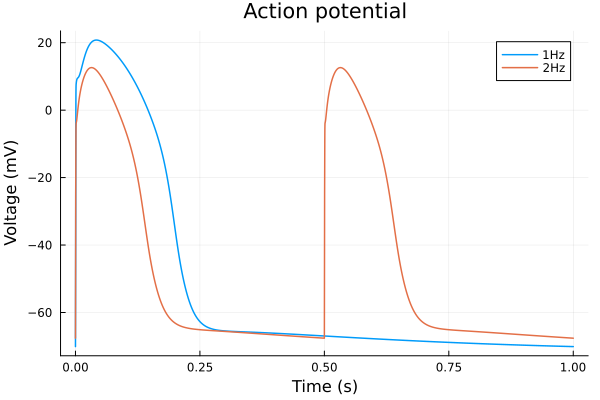

In [21]:
idxs = (sys.t / 1000 - 299, sys.vm)
plot(sol, idxs=idxs, title="Action potential", lab="1Hz", tspan=(299second, 300second))
plot!(sol2, idxs=idxs, lab="2Hz", tspan=(299second, 300second), xlabel="Time (s)", ylabel="Voltage (mV)")

In [22]:
savefig("bcl-ap.pdf")

"/home/github/actions-runner-1/_work/camkii-cardiomyocyte-model/camkii-cardiomyocyte-model/.cache/docs/bcl-ap.pdf"

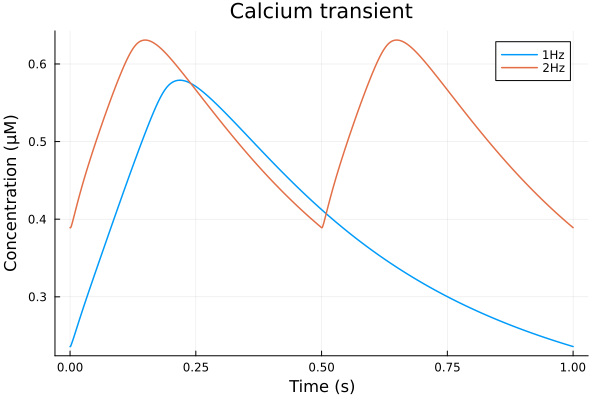

In [23]:
idxs = (sys.t / 1000 - 299, sys.Cai_mean)
plot(sol, idxs=idxs, title="Calcium transient", lab="1Hz", tspan=(299second, 300second))
plot!(sol2, idxs=idxs, lab="2Hz", tspan=(299second, 300second), xlabel="Time (s)", ylabel="Concentration (μM)")

In [24]:
savefig("bcl-cat.pdf")

"/home/github/actions-runner-1/_work/camkii-cardiomyocyte-model/camkii-cardiomyocyte-model/.cache/docs/bcl-cat.pdf"

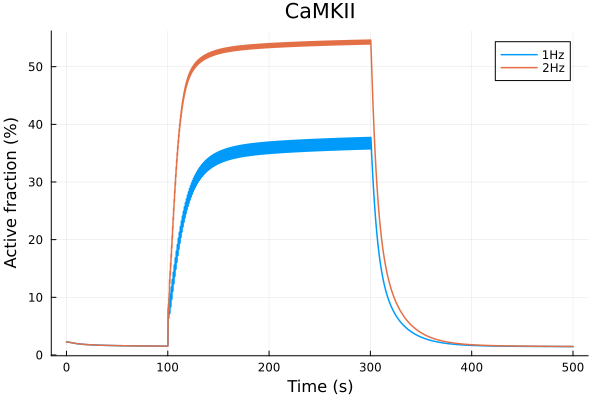

In [25]:
idxs = (sys.t / 1000, sys.CaMKAct * 100)
plot(sol, idxs=idxs, title="CaMKII", lab="1Hz")
plot!(sol2, idxs=idxs, lab="2Hz", xlabel="Time (s)", ylabel="Active fraction (%)")

In [26]:
savefig("bcl-camkact.pdf")

"/home/github/actions-runner-1/_work/camkii-cardiomyocyte-model/camkii-cardiomyocyte-model/.cache/docs/bcl-camkact.pdf"

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*